# Frontier Results: Apply, Compare, and Decide
### Apply the 4 frontier LLMs' features to all 3 datasets, retrain models, and compare against baselines and production-tier results. Closes the loop on the v2 study with a 3-tier comparison (baseline / production / frontier) and the headline statistical test.

### Setup

In [1]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


import json
import time

import pandas as pd
import numpy as np

from src.config import RESULTS_DIR
from src.data_loader import load_churn, load_housing, load_bank
from src.feature_engineer import apply_features
from src.models import evaluate_cv

### Build experiments — frontier only
##### 3 datasets × 4 frontier LLMs × 2 prompt variants × 3 ML algorithms = **72 experiments**. We skip the production tier here since notebook 04 already covered it.

In [2]:
from src.config import FRONTIER_LLMS
from itertools import product

datasets = {
    "churn": ("classification", load_churn),
    "housing": ("regression", load_housing),
    "bank": ("classification", load_bank),
}

with open(RESULTS_DIR / "llm_suggestions.json") as f:
    all_suggestions = json.load(f)

models = ["logreg", "random_forest", "xgboost"]
prompt_variants = ["zero_shot", "with_stats"]

experiments = []
for ds_name, llm_key, variant, model_name in product(
    datasets.keys(), FRONTIER_LLMS, prompt_variants, models
):
    key = f"{llm_key}__{variant}"
    if key not in all_suggestions[ds_name]:
        continue
    experiments.append(
        {
            "dataset": ds_name,
            "task": datasets[ds_name][0],
            "model": model_name,
            "feature_set": f"llm_{key}",
            "key": key,
        }
    )

print(f"{len(experiments)} new experiments queued")

72 new experiments queued


### Run the 72 frontier experiments
##### Apply each frontier LLM's features → train → cross-validate. ~2 minutes total, $0 (no LLM calls — we're reusing the suggestions from notebook 05).

In [3]:
all_rows = []
training_errors = []
start = time.perf_counter()

loaded = {ds: loader(verbose=False) for ds, (_, loader) in datasets.items()}

for i, exp in enumerate(experiments, 1):
    ds_name = exp["dataset"]
    X, y = loaded[ds_name]

    suggestions = all_suggestions[ds_name][exp["key"]]
    if not suggestions:
        print(
            f"[{i:3d}/{len(experiments)}] {ds_name:8s} | {exp['key']:32s} | {exp['model']:14s} → SKIPPED"
        )
        continue

    try:
        X_aug, report = apply_features(
            X,
            suggestions,
            dataset_name=ds_name,
            llm=exp["key"].split("__")[0],
            prompt_variant=exp["key"].split("__")[1],
            verbose=False,
        )

        result = evaluate_cv(X_aug, y, exp["model"], exp["task"])

        metric_names = (
            ["accuracy", "f1", "roc_auc"]
            if exp["task"] == "classification"
            else ["rmse", "mae", "r2"]
        )
        for m in metric_names:
            for fold_idx, score in enumerate(result[f"{m}_per_fold"]):
                all_rows.append(
                    {
                        "dataset": ds_name,
                        "task": exp["task"],
                        "model": exp["model"],
                        "feature_set": exp["feature_set"],
                        "metric": m,
                        "fold": fold_idx,
                        "value": score,
                        "n_features_added": report.n_applied,
                    }
                )

        elapsed = time.perf_counter() - start
        print(
            f"[{i:3d}/{len(experiments)}] {ds_name:8s} | {exp['key']:32s} | {exp['model']:14s} ✓  ({elapsed:.0f}s)"
        )
    except Exception as e:
        training_errors.append({**exp, "error": f"{type(e).__name__}: {e}"})
        print(
            f"[{i:3d}/{len(experiments)}] {ds_name:8s} | {exp['key']:32s} | {exp['model']:14s} ✗  ({type(e).__name__})"
        )

print(f"\nTotal: {(time.perf_counter() - start)/60:.1f} min")
print(f"Successes: {len(experiments) - len(training_errors)}/{len(experiments)}")
print(f"Errors: {len(training_errors)}")

[  1/72] churn    | gpt-5.5__zero_shot               | logreg         ✓  (0s)
[  2/72] churn    | gpt-5.5__zero_shot               | random_forest  ✓  (1s)
[  3/72] churn    | gpt-5.5__zero_shot               | xgboost        ✓  (3s)
[  4/72] churn    | gpt-5.5__with_stats              | logreg         ✓  (3s)
[  5/72] churn    | gpt-5.5__with_stats              | random_forest  ✓  (4s)
[  6/72] churn    | gpt-5.5__with_stats              | xgboost        ✓  (6s)
[  7/72] churn    | claude-opus-4.6__zero_shot       | logreg         ✓  (6s)
[  8/72] churn    | claude-opus-4.6__zero_shot       | random_forest  ✓  (7s)
[  9/72] churn    | claude-opus-4.6__zero_shot       | xgboost        ✓  (9s)
[ 10/72] churn    | claude-opus-4.6__with_stats      | logreg         ✓  (9s)
[ 11/72] churn    | claude-opus-4.6__with_stats      | random_forest  ✓  (10s)
[ 12/72] churn    | claude-opus-4.6__with_stats      | xgboost        ✓  (12s)
[ 13/72] churn    | gemini-3.1-pro__zero_shot        | logreg 

### Append to metrics_full.csv
##### Load existing results (1,755 rows from notebook 04), drop any old frontier rows defensively, then concatenate the new ones.

In [4]:
df_existing = pd.read_csv(RESULTS_DIR / "metrics_full.csv")
df_new = pd.DataFrame(all_rows)

df_existing_clean = df_existing[
    ~df_existing["feature_set"].apply(
        lambda fs: any(
            fs == f"llm_{l}__{v}" for l in FRONTIER_LLMS for v in prompt_variants
        )
    )
]

df_all = pd.concat([df_existing_clean, df_new], ignore_index=True)
df_all.to_csv(RESULTS_DIR / "metrics_full.csv", index=False)

print(f"metrics_full.csv now has {len(df_all)} rows")
print(f"   Existing: {len(df_existing_clean)} | New: {len(df_new)}")

metrics_full.csv now has 2835 rows
   Existing: 1755 | New: 1080


### Tier comparison: baseline vs production vs frontier
##### For each dataset's primary metric: average score per tier and the deltas. **The headline finding shows up here** — frontier and production are nearly identical on every dataset.

In [5]:
def assign_tier(fs):
    if fs == "baseline":
        return "baseline"
    llm = fs.replace("llm_", "").split("__")[0]
    return "frontier" if llm in FRONTIER_LLMS else "production"


df_all["tier"] = df_all["feature_set"].apply(assign_tier)

main_metric = {"churn": "roc_auc", "housing": "r2", "bank": "roc_auc"}

print("=" * 70)
print("TIER COMPARISON: BASELINE vs PRODUCTION vs FRONTIER")
print("=" * 70)

for ds in datasets:
    metric = main_metric[ds]
    sub = df_all[(df_all["dataset"] == ds) & (df_all["metric"] == metric)]

    baseline = sub[sub["tier"] == "baseline"]["value"].mean()
    prod = sub[sub["tier"] == "production"]["value"].mean()
    front = sub[sub["tier"] == "frontier"]["value"].mean()

    print(f"\n  {ds.upper()} ({metric})")
    print(f"     baseline:    {baseline:.4f}")
    print(f"     production:  {prod:.4f}  (Δ vs baseline: {prod-baseline:+.4f})")
    print(f"     frontier:    {front:.4f}  (Δ vs baseline: {front-baseline:+.4f})")
    print(f"     frontier vs production: {front-prod:+.4f}")

TIER COMPARISON: BASELINE vs PRODUCTION vs FRONTIER

  CHURN (roc_auc)
     baseline:    0.8324
     production:  0.8350  (Δ vs baseline: +0.0026)
     frontier:    0.8348  (Δ vs baseline: +0.0023)
     frontier vs production: -0.0002

  HOUSING (r2)
     baseline:    0.8926
     production:  0.8947  (Δ vs baseline: +0.0021)
     frontier:    0.8965  (Δ vs baseline: +0.0039)
     frontier vs production: +0.0018

  BANK (roc_auc)
     baseline:    0.7881
     production:  0.7881  (Δ vs baseline: -0.0000)
     frontier:    0.7884  (Δ vs baseline: +0.0003)
     frontier vs production: +0.0003


### Win rates per frontier LLM
##### For each (frontier LLM, dataset) pair: how often did the LLM-augmented model beat the baseline?

In [6]:
print("Win rates per frontier LLM (vs baseline):\n")

for llm_key in FRONTIER_LLMS:
    print(f"\n{llm_key}")
    print("-" * 50)
    for ds in datasets:
        metric = main_metric[ds]
        sub_baseline = df_all[
            (df_all["dataset"] == ds)
            & (df_all["feature_set"] == "baseline")
            & (df_all["metric"] == metric)
        ]
        sub_llm = df_all[
            (df_all["dataset"] == ds)
            & (df_all["feature_set"].str.startswith(f"llm_{llm_key}__"))
            & (df_all["metric"] == metric)
        ]

        if sub_llm.empty:
            continue

        baseline_per_model = sub_baseline.groupby("model")["value"].mean()
        llm_per_combo = sub_llm.groupby(["model", "feature_set"])[
            "value"
        ].mean()

        wins = 0
        total = 0
        for (model, fs), val in llm_per_combo.items():
            if model in baseline_per_model.index:
                total += 1
                if val > baseline_per_model[model]:
                    wins += 1

        pct = wins / total * 100 if total else 0
        print(f"  {ds:10s}: {wins}/{total} wins ({pct:.0f}%)")

Win rates per frontier LLM (vs baseline):


gpt-5.5
--------------------------------------------------
  churn     : 4/6 wins (67%)
  housing   : 4/6 wins (67%)
  bank      : 5/6 wins (83%)

claude-opus-4.6
--------------------------------------------------
  churn     : 5/6 wins (83%)
  housing   : 4/6 wins (67%)
  bank      : 4/6 wins (67%)

gemini-3.1-pro
--------------------------------------------------
  churn     : 5/6 wins (83%)
  housing   : 6/6 wins (100%)
  bank      : 4/6 wins (67%)

deepseek-v4
--------------------------------------------------
  churn     : 5/6 wins (83%)
  housing   : 6/6 wins (100%)
  bank      : 2/6 wins (33%)


### Best frontier LLM per (dataset, ML algorithm) category
##### For each (dataset, model) cell: which frontier LLM × prompt combo got the highest score? Shows that no single LLM dominates — the "best" choice depends on the downstream model.

In [7]:
print("=" * 70)
print("BEST FRONTIER LLM PER (DATASET, MODEL) CATEGORY")
print("=" * 70)

mean_results = (
    df_all.groupby(["dataset", "model", "feature_set", "metric"])["value"]
    .mean()
    .reset_index()
)

for ds in datasets:
    metric = main_metric[ds]
    print(f"\n{ds.upper()} — {metric}")
    print("-" * 70)

    sub = mean_results[
        (mean_results["dataset"] == ds) & (mean_results["metric"] == metric)
    ]
    baseline = sub[sub["feature_set"] == "baseline"].set_index("model")["value"]

    for model in models:
        b = baseline.get(model, float("nan"))
        frontier_rows = sub[
            (sub["model"] == model)
            & (
                sub["feature_set"].apply(
                    lambda fs: fs != "baseline"
                    and any(
                        fs.startswith(f"llm_{l}__") for l in FRONTIER_LLMS
                    )
                )
            )
        ].copy()

        if frontier_rows.empty:
            continue

        frontier_rows["delta"] = frontier_rows["value"] - b
        best = frontier_rows.loc[frontier_rows["value"].idxmax()]
        n_wins = (frontier_rows["delta"] > 0).sum()

        print(
            f"  {model:14s} baseline={b:.4f}  best={best['feature_set'][4:]:30s} → {best['value']:.4f}  (Δ {best['delta']:+.4f}, {n_wins}/{len(frontier_rows)} wins)"
        )

BEST FRONTIER LLM PER (DATASET, MODEL) CATEGORY

CHURN — roc_auc
----------------------------------------------------------------------
  logreg         baseline=0.8451  best=claude-opus-4.6__zero_shot     → 0.8484  (Δ +0.0033, 6/8 wins)
  random_forest  baseline=0.8217  best=gemini-3.1-pro__with_stats     → 0.8295  (Δ +0.0078, 8/8 wins)
  xgboost        baseline=0.8305  best=claude-opus-4.6__zero_shot     → 0.8338  (Δ +0.0033, 5/8 wins)

HOUSING — r2
----------------------------------------------------------------------
  logreg         baseline=0.8691  best=gpt-5.5__with_stats            → 0.8746  (Δ +0.0055, 5/8 wins)
  random_forest  baseline=0.8963  best=gpt-5.5__zero_shot             → 0.9060  (Δ +0.0097, 8/8 wins)
  xgboost        baseline=0.9125  best=claude-opus-4.6__zero_shot     → 0.9199  (Δ +0.0074, 7/8 wins)

BANK — roc_auc
----------------------------------------------------------------------
  logreg         baseline=0.7916  best=gpt-5.5__zero_shot             → 0.7922  

### Tier distribution boxplot
##### One boxplot per dataset showing the spread of all (LLM × prompt × algorithm) scores per tier. Visual confirmation that the three tiers overlap heavily — there's no clear winner.

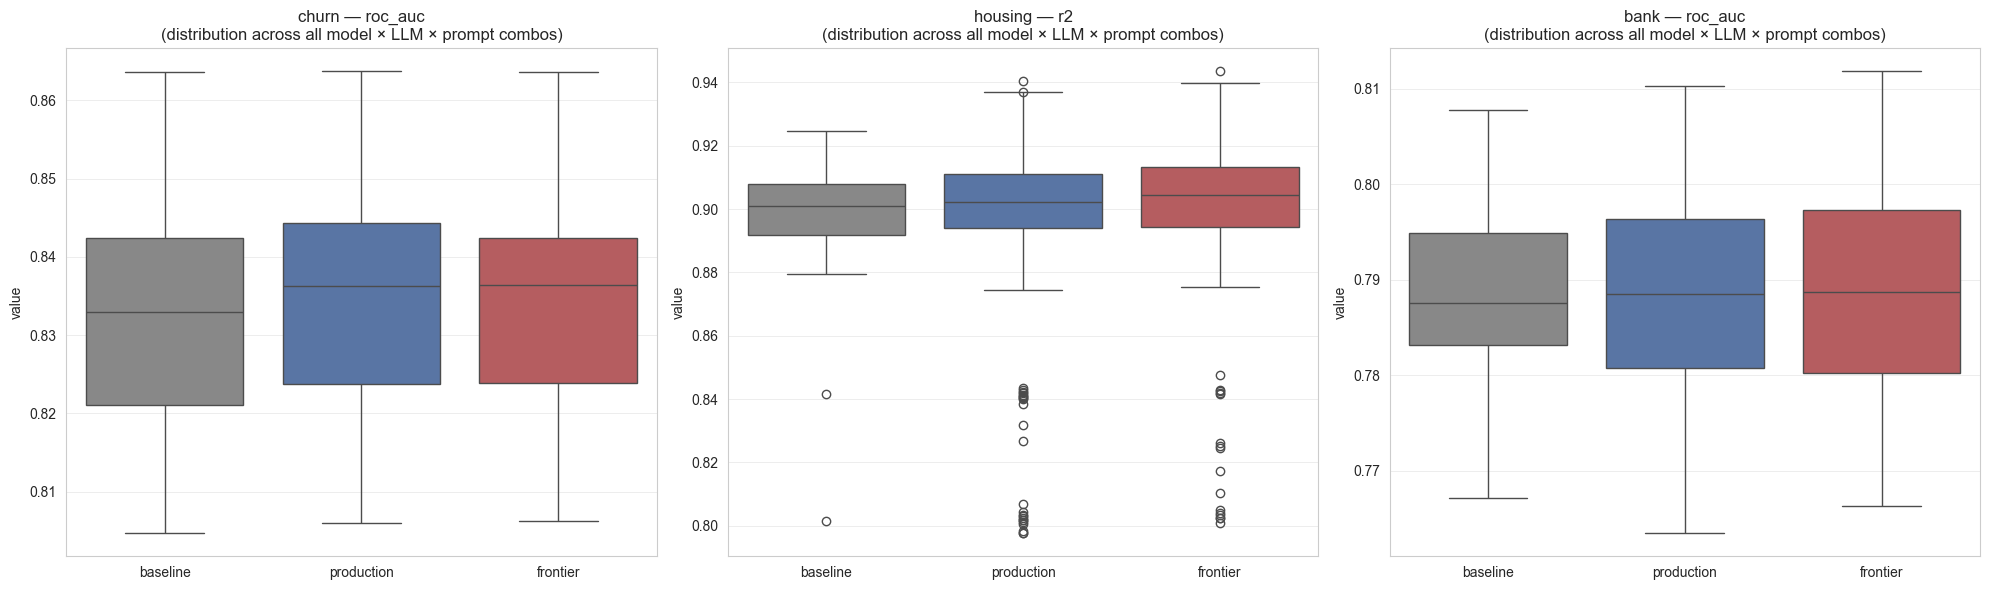

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.config import FIGURES_DIR

sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

palette = {"baseline": "#888888", "production": "#4C72B0", "frontier": "#C44E52"}

for ax, ds in zip(axes, datasets):
    metric = main_metric[ds]
    sub = df_all[(df_all["dataset"] == ds) & (df_all["metric"] == metric)].copy()

    sns.boxplot(
        data=sub,
        x="tier",
        y="value",
        order=["baseline", "production", "frontier"],
        hue="tier",
        palette=palette,
        legend=False,
        ax=ax,
    )
    ax.set_title(
        f"{ds} — {metric}\n(distribution across all model × LLM × prompt combos)"
    )
    ax.set_xlabel("")

plt.tight_layout()
plt.savefig(
    FIGURES_DIR / "09_frontier_vs_production.png",
    bbox_inches="tight",
    dpi=120,
)
plt.show()

### Statistical test: frontier vs production
##### Mann-Whitney U test (non-parametric, doesn't assume normality) on the full distribution of scores. **The killer p-values: 0.92, 0.34, 0.91 — no statistically significant difference on any dataset, despite n=300 per comparison.**

In [9]:
from scipy.stats import mannwhitneyu

print("=" * 70)
print("STATISTICAL TEST: Frontier vs Production (Mann-Whitney U)")
print("=" * 70)
print(
    "(Tests whether frontier features produce significantly different scores)\n"
)

for ds in datasets:
    metric = main_metric[ds]
    sub = df_all[(df_all["dataset"] == ds) & (df_all["metric"] == metric)]

    prod_scores = sub[sub["tier"] == "production"]["value"].values
    front_scores = sub[sub["tier"] == "frontier"]["value"].values

    if len(prod_scores) == 0 or len(front_scores) == 0:
        continue

    u, p = mannwhitneyu(front_scores, prod_scores, alternative="two-sided")
    diff = front_scores.mean() - prod_scores.mean()

    sig = (
        "✓ frontier significantly different"
        if p < 0.05
        else "✗ no significant difference"
    )
    direction = "HIGHER" if diff > 0 else "LOWER" if diff < 0 else "EQUAL"

    print(f"\n{ds.upper()} ({metric})")
    print(
        f"  production: mean={prod_scores.mean():.4f}  (n={len(prod_scores)})"
    )
    print(f"  frontier:   mean={front_scores.mean():.4f}  (n={len(front_scores)})")
    print(f"  Δ = {diff:+.4f} ({direction})")
    print(f"  p-value = {p:.4f}  →  {sig}")

STATISTICAL TEST: Frontier vs Production (Mann-Whitney U)
(Tests whether frontier features produce significantly different scores)


CHURN (roc_auc)
  production: mean=0.8350  (n=180)
  frontier:   mean=0.8348  (n=120)
  Δ = -0.0002 (LOWER)
  p-value = 0.9161  →  ✗ no significant difference

HOUSING (r2)
  production: mean=0.8947  (n=180)
  frontier:   mean=0.8965  (n=120)
  Δ = +0.0018 (HIGHER)
  p-value = 0.3413  →  ✗ no significant difference

BANK (roc_auc)
  production: mean=0.7881  (n=180)
  frontier:   mean=0.7884  (n=120)
  Δ = +0.0003 (HIGHER)
  p-value = 0.9086  →  ✗ no significant difference


### v2 research summary
##### Win rates broken down by tier and dataset. Confirms the pattern: production wins more often on Churn (where the baseline is harder to beat); frontier wins slightly more on Housing/Bank (where the baseline has more room to grow).

In [10]:
print("=" * 70)
print("v2 RESEARCH SUMMARY — 10 LLMs across 2 generations")
print("=" * 70)

# Total experiments
total_exp = (
    df_all[df_all["feature_set"] != "baseline"][
        ["dataset", "feature_set", "model"]
    ]
    .drop_duplicates()
    .shape[0]
)
print(f"\nTotal LLM-augmented experiments: {total_exp}")

# Win rates per tier
print("\nWin rates per dataset (% LLM combos beating baseline):")
for ds in datasets:
    metric = main_metric[ds]
    sub = mean_results[
        (mean_results["dataset"] == ds) & (mean_results["metric"] == metric)
    ]
    baseline = sub[sub["feature_set"] == "baseline"].set_index("model")["value"]

    for tier_name, llm_list in [("production", []), ("frontier", FRONTIER_LLMS)]:
        if tier_name == "production":
            tier_rows = sub[
                sub["feature_set"].apply(
                    lambda fs: fs != "baseline"
                    and not any(
                        fs.startswith(f"llm_{l}__") for l in FRONTIER_LLMS
                    )
                )
            ].copy()
        else:
            tier_rows = sub[
                sub["feature_set"].apply(
                    lambda fs: fs != "baseline"
                    and any(fs.startswith(f"llm_{l}__") for l in FRONTIER_LLMS)
                )
            ].copy()

        tier_rows["delta"] = tier_rows.apply(
            lambda r: r["value"] - baseline.get(r["model"], float("nan")),
            axis=1,
        )
        n_wins = (tier_rows["delta"] > 0).sum()
        n_total = len(tier_rows)
        rate = n_wins / n_total if n_total else 0
        print(f"   {ds:10s} {tier_name:11s}: {n_wins}/{n_total} ({rate:.1%})")

v2 RESEARCH SUMMARY — 10 LLMs across 2 generations

Total LLM-augmented experiments: 180

Win rates per dataset (% LLM combos beating baseline):
   churn      production : 33/36 (91.7%)
   churn      frontier   : 19/24 (79.2%)
   housing    production : 22/36 (61.1%)
   housing    frontier   : 20/24 (83.3%)
   bank       production : 16/36 (44.4%)
   bank       frontier   : 15/24 (62.5%)


### Per-LLM detailed analysis
##### The full picture: validity, cost, latency, win rate, and average improvement for each of the 10 LLMs, sorted by cost per valid feature.

In [11]:
print("=" * 100)
print("PER-LLM DETAILED ANALYSIS")
print("=" * 100)

df_metrics = pd.read_csv(RESULTS_DIR / "llm_metrics.csv")
df_validity = pd.read_csv(RESULTS_DIR / "validity_rates.csv")

# Cost & validity per LLM
cost_per_llm = (
    df_metrics.groupby("llm")
    .agg(
        total_cost=("cost_usd", "sum"),
        mean_latency=("latency_s", "mean"),
    )
    .reset_index()
)

val_per_llm = (
    df_validity.groupby("llm")
    .agg(
        total_valid=("n_applied", "sum"),
        total_suggested=("n_suggested", "sum"),
    )
    .reset_index()
)

llm_stats = cost_per_llm.merge(val_per_llm, on="llm")
llm_stats["validity_rate"] = llm_stats["total_valid"] / llm_stats[
    "total_suggested"
].clip(lower=1)
llm_stats["cost_per_valid"] = (
    llm_stats["total_cost"] / llm_stats["total_valid"].clip(lower=1)
)

# Win rate + avg improvement per LLM
mean_results = (
    df_all.groupby(["dataset", "model", "feature_set", "metric"])["value"]
    .mean()
    .reset_index()
)

llm_perf = []
for llm_key in llm_stats["llm"]:
    wins, total, deltas = 0, 0, []
    for ds in datasets:
        metric = main_metric[ds]
        sub = mean_results[
            (mean_results["dataset"] == ds) & (mean_results["metric"] == metric)
        ]
        baseline_per_model = sub[sub["feature_set"] == "baseline"].set_index(
            "model"
        )["value"]
        llm_rows = sub[sub["feature_set"].str.startswith(f"llm_{llm_key}__")]
        for _, r in llm_rows.iterrows():
            b = baseline_per_model.get(r["model"])
            if b is None:
                continue
            d = r["value"] - b
            deltas.append(d)
            total += 1
            if d > 0:
                wins += 1
    llm_perf.append(
        {
            "llm": llm_key,
            "win_rate": wins / total if total else 0,
            "wins": f"{wins}/{total}",
            "avg_improvement": np.mean(deltas) if deltas else 0,
        }
    )

df_perf = pd.DataFrame(llm_perf)
final = llm_stats.merge(df_perf, on="llm")
final["tier"] = final["llm"].apply(
    lambda x: "frontier" if x in FRONTIER_LLMS else "production"
)
final = final.sort_values("cost_per_valid").round(6)

# Print clean version
print(
    f"\n{'LLM':18s} {'tier':11s} {'validity':>10s} {'$/valid':>10s} {'wins':>9s} {'win%':>7s} {'avg Δ':>9s}"
)
print("-" * 80)
for _, r in final.iterrows():
    print(
        f"{r['llm']:18s} {r['tier']:11s} {r['validity_rate']:>9.1%} {r['cost_per_valid']:>10.6f} {r['wins']:>9s} {r['win_rate']:>6.1%} {r['avg_improvement']:>+9.4f}"
    )


PER-LLM DETAILED ANALYSIS

LLM                tier          validity    $/valid      wins    win%     avg Δ
--------------------------------------------------------------------------------
gemini-flash       production      90.5%   0.000046     12/18  66.7%   +0.0012
llama-3.3          production      85.7%   0.000046     10/18  55.6%   +0.0009
gpt-4o-mini        production      92.9%   0.000057      9/18  50.0%   +0.0005
qwen-2.5           production      95.2%   0.000078     13/18  72.2%   +0.0025
deepseek-v3        production      85.7%   0.000119     13/18  72.2%   +0.0021
deepseek-v4        frontier        97.6%   0.001219     13/18  72.2%   +0.0017
claude-sonnet      production      90.5%   0.001720     14/18  77.8%   +0.0021
claude-opus-4.6    frontier        90.5%   0.002989     13/18  72.2%   +0.0026
gemini-3.1-pro     frontier        92.9%   0.005414     15/18  83.3%   +0.0025
gpt-5.5            frontier       100.0%   0.007216     13/18  72.2%   +0.0020


### LLM × ML algorithm matrix
##### For each (LLM, ML algorithm): wins out of 6 conditions (3 datasets × 2 prompts). The bottom-line averages reveal the project's **most actionable finding** — XGBoost averages 76% wins, LogReg only 50%.

In [12]:
main_metric = {"churn": "roc_auc", "housing": "r2", "bank": "roc_auc"}

ALL_LLMS = [
    "gpt-4o-mini",
    "claude-sonnet",
    "gemini-flash",
    "deepseek-v3",
    "llama-3.3",
    "qwen-2.5",
    "gpt-5.5",
    "claude-opus-4.6",
    "gemini-3.1-pro",
    "deepseek-v4",
]

mean_results = (
    df_all.groupby(["dataset", "model", "feature_set", "metric"])["value"]
    .mean()
    .reset_index()
)

matrix = []
for llm_key in ALL_LLMS:
    row = {"LLM": llm_key}
    for ml_model in ["logreg", "random_forest", "xgboost"]:
        wins = 0
        total = 0
        for ds in ["churn", "housing", "bank"]:
            metric = main_metric[ds]
            sub = mean_results[
                (mean_results["dataset"] == ds)
                & (mean_results["model"] == ml_model)
                & (mean_results["metric"] == metric)
            ]
            baseline_val = sub[sub["feature_set"] == "baseline"]["value"]
            if baseline_val.empty:
                continue
            b = baseline_val.iloc[0]

            for variant in ["zero_shot", "with_stats"]:
                fs = f"llm_{llm_key}__{variant}"
                llm_val = sub[sub["feature_set"] == fs]["value"]
                if llm_val.empty:
                    continue
                total += 1
                if llm_val.iloc[0] > b:
                    wins += 1
        row[ml_model] = f"{wins}/{total}" if total else "—"
    matrix.append(row)

df_matrix = pd.DataFrame(matrix)
print(
    "LLM × ML algorithm — wins out of 6 conditions (3 datasets × 2 prompts):\n"
)
print(df_matrix.to_string(index=False))

LLM × ML algorithm — wins out of 6 conditions (3 datasets × 2 prompts):

            LLM logreg random_forest xgboost
    gpt-4o-mini    3/6           2/6     4/6
  claude-sonnet    4/6           4/6     6/6
   gemini-flash    3/6           5/6     4/6
    deepseek-v3    2/6           5/6     6/6
      llama-3.3    3/6           3/6     4/6
       qwen-2.5    2/6           5/6     6/6
        gpt-5.5    4/6           6/6     3/6
claude-opus-4.6    3/6           5/6     5/6
 gemini-3.1-pro    4/6           5/6     6/6
    deepseek-v4    4/6           4/6     5/6
